In [1]:
from importlib.resources import files, as_file
import numpy as np
import matplotlib.pyplot as plt
from nsbutils.plotting import plot_surf
from neuromodes.eigen import EigenSolver
from neuromodes.io import fetch_example_surf, fetch_example_map
from neuromodes.mesh import unmask_data
from neuromodes.stats import cdistw

In [2]:
# Configuration
density = "32k"
n_modes = 15**2   # First 15 eigengroups
n_nulls = 1000
seed = 0

In [3]:
hemi = 'L'
surf_type = 'midthickness'
mesh, medmask = fetch_example_surf(density=density, hemi='L', surf_type='midthickness')
myelinmap = fetch_example_map('myelinmap', density=density)[medmask]

solver = EigenSolver(mesh, mask=medmask).solve(n_modes)

In [4]:
# Calculate nulls
nulls = solver.flip_coeffs(myelinmap, n_nulls=n_nulls, seed=seed)
print(nulls.shape)

(29696, 1000)


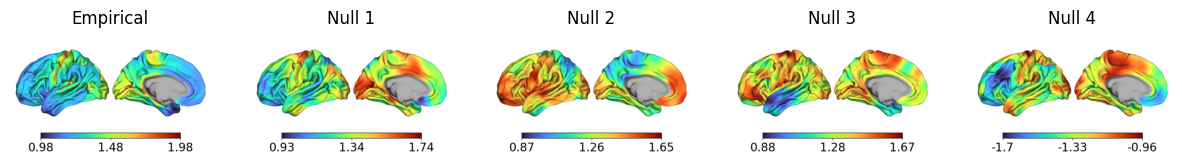

In [5]:
# Plot nulls
lh_surfpath = files('neuromodes.data') / f'sp-human_tpl-fsLR_den-{density}_hemi-{hemi}_{surf_type}.surf.gii'

with as_file(lh_surfpath) as lh_surfpath:
    fig1, axs = plt.subplots(1, 5, figsize=(15, 6))
    axs = axs.ravel()
    for i, ax_i in enumerate(axs):
        if i == 0:
            data = unmask_data(myelinmap, medmask)
            title = "Empirical"
        else:
            data = unmask_data(nulls[:, i-1], medmask)
            title = f"Null {i}"

        plot_surf(lh_surfpath, data, cmap="turbo", ax=axs[i], cbar=True)
        axs[i].set_title(title)

Let's also plot the distribution of correlation coefficients between every pair of null maps.

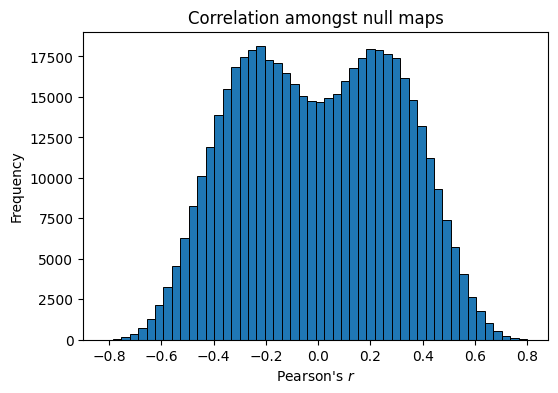

In [23]:
# Plot null correlation distribution
inter_null_corrs = 1-cdistw(nulls, nulls, mass=solver.mass, metric="correlation")
triu_inds = np.triu_indices_from(inter_null_corrs, k=1)
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(inter_null_corrs[triu_inds], bins=50, edgecolor='black', linewidth=0.7)
ax2.set_title("Correlation amongst null maps")
ax2.set_xlabel("Pearson's $r$")
ax2.set_ylabel("Frequency")

plt.show()

Observed correlation between myelinmap and fcgradient1: -0.5742
p-value: 0.0050


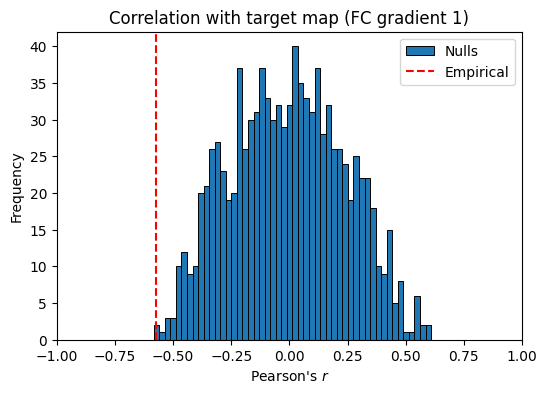

In [10]:
fcgrad = fetch_example_map("fcgradient1", density=density)[medmask]

# Compute correlation between myelinmap and fcgradient1
corr = 1-cdistw(myelinmap, fcgrad, mass=solver.mass, metric="correlation")[0][0]

# Compute correlation between fcgradient1 and nulls
null_corrs = 1-cdistw(fcgrad, nulls, mass=solver.mass, metric="correlation")[0]

pvalue = (np.sum(np.abs(null_corrs) >= np.abs(corr)) + 1) / (n_nulls + 1)
print(f"Observed correlation between myelinmap and fcgradient1: {corr:.4f}")
print(f"p-value: {pvalue:.4f}")

# Plot correlation distributions
fig, ax_i = plt.subplots(figsize=(6, 4))
ax_i.hist(null_corrs, bins=50, edgecolor="black", linewidth=0.7, label="Nulls")
ax_i.axvline(corr, color="red", linestyle="--", label="Empirical")
ax_i.set_title("Correlation with target map (FC gradient 1)")
ax_i.set_xlabel("Pearson's $r$")
ax_i.set_ylabel("Frequency")
ax_i.set_xlim(-1, 1)
ax_i.legend()
plt.show()

### Try nulling SA axis instead

In [8]:
nulls_fcgrad = solver.flip_coeffs(fcgrad, n_nulls=n_nulls, seed=seed)

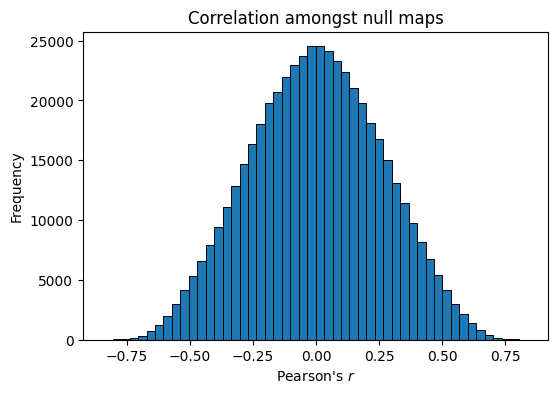

In [9]:
# Plot null correlation distribution
inter_null_corrs = 1-cdistw(nulls_fcgrad, nulls_fcgrad, mass=solver.mass, metric="correlation")
triu_inds = np.triu_indices_from(inter_null_corrs, k=1)
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(inter_null_corrs[triu_inds], bins=50, edgecolor='black', linewidth=0.7)
ax2.set_title("Correlation amongst null maps")
ax2.set_xlabel("Pearson's $r$")
ax2.set_ylabel("Frequency")

plt.show()

Observed correlation between myelinmap and fcgradient1: -0.5742
p-value: 0.0040


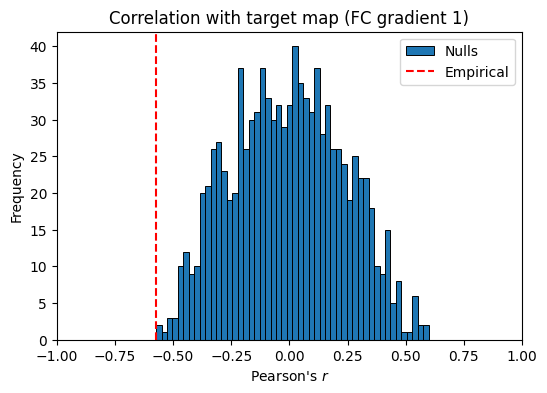

In [11]:
# Compute correlation between myelinmap and nulls
null_corrs = 1-cdistw(myelinmap, nulls_fcgrad, mass=solver.mass, metric="correlation")[0]

pvalue = (np.sum(np.abs(null_corrs) >= np.abs(corr)) + 1) / (n_nulls + 1)
print(f"Observed correlation between myelinmap and fcgradient1: {corr:.4f}")
print(f"p-value: {pvalue:.4f}")

# Plot correlation distributions
fig, ax_i = plt.subplots(figsize=(6, 4))
ax_i.hist(null_corrs, bins=50, edgecolor="black", linewidth=0.7, label="Nulls")
ax_i.axvline(corr, color="red", linestyle="--", label="Empirical")
ax_i.set_title("Correlation with target map (FC gradient 1)")
ax_i.set_xlabel("Pearson's $r$")
ax_i.set_ylabel("Frequency")
ax_i.set_xlim(-1, 1)
ax_i.legend()
plt.show()

In [12]:
# calculation proportion of power in first 15**2 modes for myelinmap and fcgradient1
total_power_myelinmap = myelinmap.T @ solver.mass @ myelinmap
total_power_fcgrad = fcgrad.T @ solver.mass @ fcgrad
prop_power_myelinmap = (solver.decompose(myelinmap)**2).sum() / total_power_myelinmap
prop_power_fcgrad = (solver.decompose(fcgrad)**2).sum() / total_power_fcgrad
print(f"Proportion of power in first {n_modes} modes for myelinmap: {prop_power_myelinmap:.4f}")
print(f"Proportion of power in first {n_modes} modes for fcgradient1: {prop_power_fcgrad:.4f}")

Proportion of power in first 225 modes for myelinmap: 0.9993
Proportion of power in first 225 modes for fcgradient1: 0.9719


In [13]:
# calculate rayleigh quotient for myelinmap and its nulls
rq_empirical = (myelinmap.T @ solver.stiffness @ myelinmap) / (myelinmap.T @ solver.mass @ myelinmap)
rq_nulls = np.array([(nulls[:, i].T @ solver.stiffness @ nulls[:, i]) / (nulls[:, i].T @ solver.mass @ nulls[:, i]) for i in range(n_nulls)])

In [18]:
print(f'Rayleigh quotient for myelinmap: {rq_empirical}')
rq_nulls

Rayleigh quotient for myelinmap: 0.00013834428338724695


array([5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
       5.28867492e-05, 5.28867492e-05, 5.28867492e-05, 5.28867492e-05,
      

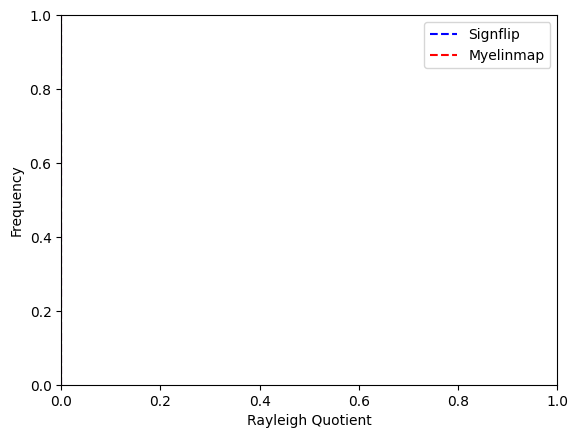

In [ ]:
# plot two vertical lines for the Rayleigh quotients of the myelinmap and the first null
plt.xlabel('Rayleigh Quotient')
plt.ylabel('Frequency')
plt.legend()
plt.show()